In [ ]:
# ===========================
# 1. Cargar y explorar dataset
# ===========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset('mpg')

# Mostrar columnas disponibles
df.columns
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
# Eliminar filas con valores faltantes
df = df.dropna()

# Si existe 'origin', convertimos a dummies. Si no, seguimos sin ella.
if 'origin' in df.columns:
    df = pd.get_dummies(df, columns=['origin'], drop_first=True)
else:
    print("⚠️ Columna 'origin' no encontrada. Continuando sin codificación categórica.")

# Seleccionar variables predictoras (todas las numéricas excepto mpg)
X = df.select_dtypes(include='number').drop(columns=['mpg'])
y = df['mpg']

print("Columnas de entrada (features):", X.columns.tolist())

Columnas de entrada (features): ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(16, 8),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.01,
                   max_iter=1000,
                   random_state=42)

mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(16, 8), learning_rate_init=0.01, max_iter=1000,
             random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = mlp.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio (MSE):", round(mse, 2))
print("Coeficiente de determinación (R²):", round(r2, 3))

Error cuadrático medio (MSE): 6.67
Coeficiente de determinación (R²): 0.869


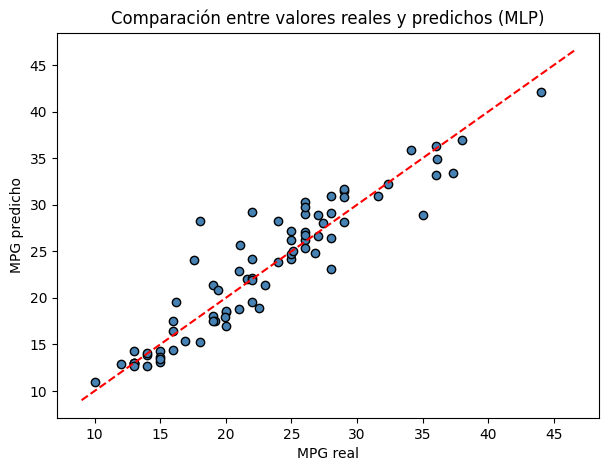

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, c='steelblue', edgecolor='k')
plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Comparación entre valores reales y predichos (MLP)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Regresión lineal - MSE:", round(mse_lr, 2))
print("Regresión lineal - R²:", round(r2_lr, 3))

Regresión lineal - MSE: 10.5
Regresión lineal - R²: 0.794


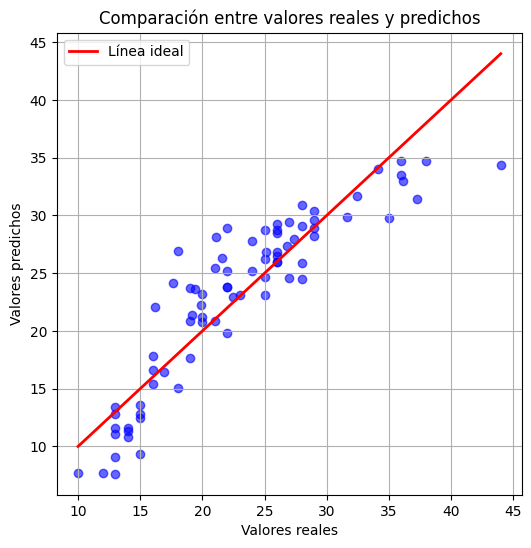

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Línea ideal')
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Comparación entre valores reales y predichos")
plt.legend()
plt.grid(True)
plt.show()